# Zambia Power Lines: Cables vs. Circuits

Two separate maps of the OSM power-line network (`out/zambia_line.geojson`):
one colored by **number of cables** (`tags.cables`), the other by
**number of circuits** (`tags.circuits`). Lines with a missing value are
drawn in gray as "Unknown".

You will have to have the Earth OSM package installed on your machine and run it for the country in this case, for Zambia. Instructions can be found [here](https://github.com/pypsa-meets-earth/earth-osm)

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("out/zambia_line.geojson")
print(f"{len(gdf)} power line segments")
gdf[["tags.cables", "tags.circuits"]].describe(include="all")

Skipping field refs: unsupported OGR type: 13


664 power line segments


,tags.cables,tags.circuits
count,368.000000,359.000000
mean,3.220109,1.075209
std,0.783291,0.264096
min,3.000000,1.000000
25%,3.000000,1.000000
50%,3.000000,1.000000
75%,3.000000,1.000000
max,6.000000,2.000000


## Value counts

In [2]:
print("Cables:")
print(gdf["tags.cables"].value_counts(dropna=False).sort_index())
print()
print("Circuits:")
print(gdf["tags.circuits"].value_counts(dropna=False).sort_index())

Cables:
tags.cables
3.0    341
6.0     27
NaN    296
Name: count, dtype: int64

Circuits:
tags.circuits
1.0    332
2.0     27
NaN    305
Name: count, dtype: int64


## Plot helper

Each category gets a fixed color from a small categorical palette; segments
with no tag value are drawn in gray as "Unknown" underneath.

In [3]:
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue, orange, aqua, yellow
UNKNOWN_COLOR = "#898781"


def plot_by_category(gdf, column, title, legend_title):
    fig, ax = plt.subplots(figsize=(8, 10))

    unknown = gdf[gdf[column].isna()]
    if not unknown.empty:
        unknown.plot(ax=ax, color=UNKNOWN_COLOR, linewidth=1.0, linestyle="--",
                     label="Unknown", zorder=2)

    categories = sorted(gdf[column].dropna().unique())
    for color, cat in zip(CATEGORY_COLORS, categories):
        subset = gdf[gdf[column] == cat]
        label = f"{int(cat)}"
        subset.plot(ax=ax, color=color, linewidth=1.8, label=label, zorder=3)

    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.legend(loc="lower left", frameon=True, title=legend_title)
    fig.tight_layout()
    return fig, ax

## Number of cables

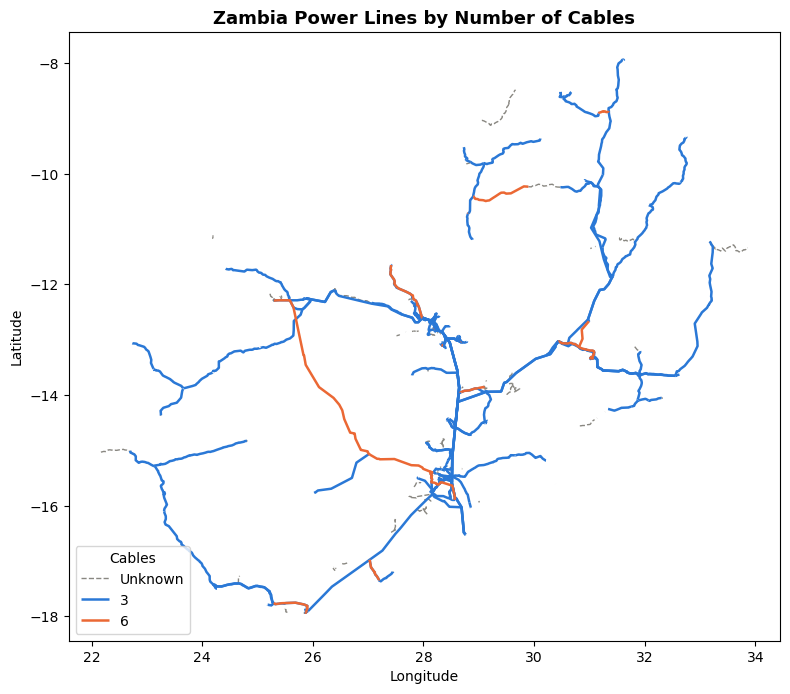

In [4]:
plot_by_category(
    gdf,
    column="tags.cables",
    title="Zambia Power Lines by Number of Cables",
    legend_title="Cables",
)
plt.show()

## Number of circuits

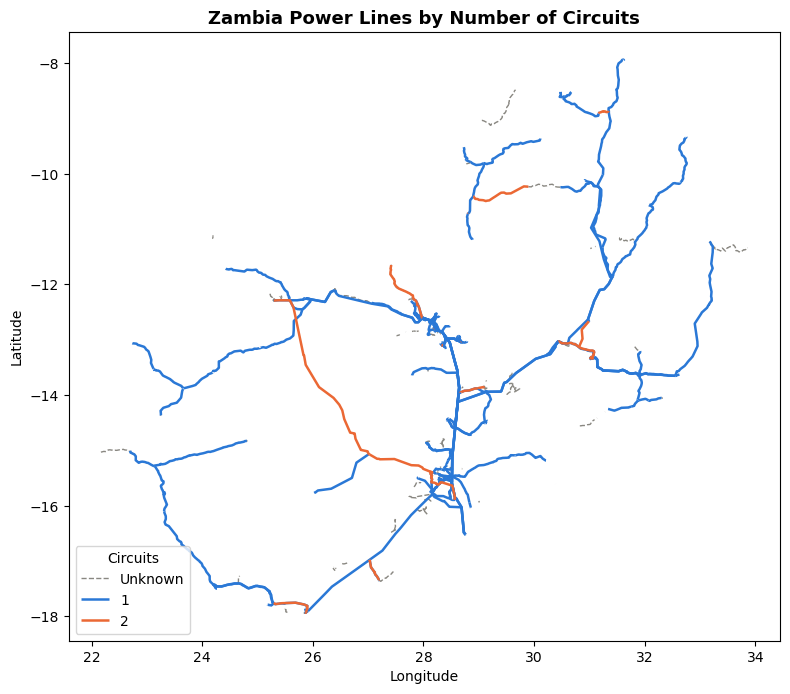

In [5]:
plot_by_category(
    gdf,
    column="tags.circuits",
    title="Zambia Power Lines by Number of Circuits",
    legend_title="Circuits",
)
plt.show()